In [1]:
data_root       = "./data"
test_splits_dir = "./test_splits"
save_dir        = "./project_outputs"

TEST_SPLITS = ["clean", "blur_little", "blur_medium", "downsampled", "masked", "noise_rotation"]

num_classes     = 101
image_size      = 224
batch_size      = 32
num_workers     = 4   # set to 0 if DataLoader hangs on Windows

baseline_epochs = 3
peft_epochs     = 3
improved_epochs = 4
val_ratio       = 0.1

import os
for d in [save_dir, os.path.join(save_dir, "checkpoints"), os.path.join(save_dir, "figures")]:
    os.makedirs(d, exist_ok=True)

print("test_splits_dir exists:", os.path.exists(test_splits_dir))
for sp in TEST_SPLITS:
    print(f"  {sp}:", os.path.exists(os.path.join(test_splits_dir, sp)))

test_splits_dir exists: True
  clean: True
  blur_little: True
  blur_medium: True
  downsampled: True
  masked: True
  noise_rotation: True


In [2]:
%pip install peft fvcore grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import time
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder

from peft import LoraConfig, get_peft_model
from fvcore.nn import FlopCountAnalysis
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print(torch.cuda.get_device_name(0))

c:\Users\1\Downloads\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
NVIDIA GeForce RTX 5060


In [4]:
base_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

aug_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
full_train = datasets.Food101(root=data_root, split="train", download=True, transform=base_transform)

val_size   = int(len(full_train) * val_ratio)
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

full_train_aug    = datasets.Food101(root=data_root, split="train", download=False, transform=aug_transform)
train_dataset_aug = torch.utils.data.Subset(full_train_aug, train_dataset.indices)

_kw = dict(num_workers=num_workers, pin_memory=(device == "cuda"),
           persistent_workers=(num_workers > 0))
train_loader     = DataLoader(train_dataset,     batch_size=batch_size, shuffle=True,  **_kw)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True,  **_kw)
val_loader       = DataLoader(val_dataset,       batch_size=batch_size, shuffle=False, **_kw)

print("train:", len(train_dataset), " val:", len(val_dataset))

100%|██████████| 5.00G/5.00G [05:00<00:00, 16.6MB/s]  


train: 68175  val: 7575


In [6]:
test_loaders = {}
for split_name in TEST_SPLITS:
    split_path = os.path.join(test_splits_dir, split_name)
    ds = ImageFolder(root=split_path, transform=base_transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=(device == "cuda"))
    test_loaders[split_name] = dl
    print(split_name, len(ds))

class_names = datasets.Food101(root=data_root, split="train", download=False).classes

clean 25250
blur_little 25250
blur_medium 25250
downsampled 25250
masked 25250
noise_rotation 25250


In [7]:
def get_base_model(model_name, num_classes=101):
    if model_name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif model_name == "efficientnet_v2_s":
        m = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"unsupported model_name: {model_name}")
    return m


def freeze_all_except_head(model, model_name):
    for p in model.parameters():
        p.requires_grad = False
    if model_name == "resnet18":
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier[1].parameters():
            p.requires_grad = True
    return model


def batchnorm_tuning(model, model_name):
    for p in model.parameters():
        p.requires_grad = False
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            if m.weight is not None:
                m.weight.requires_grad = True
            if m.bias is not None:
                m.bias.requires_grad = True
    if model_name == "resnet18":
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier[1].parameters():
            p.requires_grad = True
    return model


def get_lora_target_modules(model, model_name):
    targets = []
    if model_name == "resnet18":
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d) and module.groups == 1:
                if any(name.startswith(p) for p in ("layer3", "layer4")):
                    targets.append(name)
    else:
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d) and module.groups == 1:
                if any(name.startswith(p) for p in ("features.5", "features.6", "features.7")):
                    targets.append(name)
        targets.append("classifier.1")
    targets = sorted(set(targets))
    if not targets:
        raise ValueError(f"no LoRA target modules found for {model_name}")
    return targets


def apply_lora(model, model_name):
    target_modules = get_lora_target_modules(model, model_name)
    config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=target_modules,
        lora_dropout=0.1,
        bias="none",
    )
    model = get_peft_model(model, config)
    if model_name == "resnet18":
        for p in model.base_model.model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.base_model.model.classifier[1].parameters():
            p.requires_grad = True
    return model


class ConvBottleneckAdapter(nn.Module):
    def __init__(self, channels, bottleneck=64):
        super().__init__()
        hidden = min(bottleneck, max(8, channels // 4))
        self.down = nn.Conv2d(channels, hidden, kernel_size=1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.up   = nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        nn.init.kaiming_normal_(self.down.weight, nonlinearity="relu")
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        return x + self.up(self.relu(self.down(x)))


class ResNet18TSA(nn.Module):
    def __init__(self, num_classes=101, bottleneck=64):
        super().__init__()
        bb = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = bb.fc.in_features
        bb.fc = nn.Identity()
        self.backbone   = bb
        self.adapter    = ConvBottleneckAdapter(channels=512, bottleneck=bottleneck)
        self.classifier = nn.Linear(feat_dim, num_classes)
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in list(self.adapter.parameters()) + list(self.classifier.parameters()):
            p.requires_grad = True

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.adapter(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class EfficientNetV2STSA(nn.Module):
    def __init__(self, num_classes=101, bottleneck=64):
        super().__init__()
        bb = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        feat_dim = bb.classifier[1].in_features
        bb.classifier = nn.Identity()
        self.backbone   = bb
        self.adapter    = ConvBottleneckAdapter(channels=feat_dim, bottleneck=bottleneck)
        self.classifier = nn.Linear(feat_dim, num_classes)
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in list(self.adapter.parameters()) + list(self.classifier.parameters()):
            p.requires_grad = True

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.adapter(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_tsa_model(model_name, num_classes=101):
    if model_name == "resnet18":
        return ResNet18TSA(num_classes=num_classes)
    elif model_name == "efficientnet_v2_s":
        return EfficientNetV2STSA(num_classes=num_classes)
    else:
        raise ValueError(f"unsupported model_name for tsa: {model_name}")


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_trainable_summary(model, name):
    t = count_trainable_params(model)
    total = sum(p.numel() for p in model.parameters())
    print(f"  {name}: {t:,} / {total:,} trainable ({100 * t / total:.2f}%)")

In [8]:
def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).sum().item(), labels.size(0)


def evaluate_model(model, data_loader, device):
    model.eval()
    total_correct = 0
    total_correct5 = 0
    total_seen = 0
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            total_correct  += (out.argmax(1) == y).sum().item()
            top5 = out.topk(min(5, out.size(1)), dim=1).indices
            total_correct5 += (top5 == y.unsqueeze(1)).any(1).sum().item()
            total_seen     += y.size(0)
    return {
        "loss":     total_loss / total_seen,
        "accuracy": total_correct  / total_seen,
        "top5_acc": total_correct5 / total_seen,
    }


def train_model(model, train_loader, val_loader, device,
                num_epochs=3, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable, lr=lr, weight_decay=weight_decay)

    best_state   = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    history      = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_correct, running_seen = 0.0, 0, 0
        start = time.time()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            c, n = accuracy_from_logits(out, y)
            running_correct += c
            running_seen    += n
            running_loss    += loss.item() * n

        train_loss = running_loss / running_seen
        train_acc  = running_correct / running_seen
        val_m      = evaluate_model(model, val_loader, device)
        val_acc    = val_m["accuracy"]
        elapsed    = time.time() - start

        history.append({
            "epoch":     epoch + 1,
            "train_loss": train_loss,
            "train_acc":  train_acc,
            "val_loss":   val_m["loss"],
            "val_acc":    val_acc,
            "val_top5":   val_m["top5_acc"],
            "time_sec":   elapsed,
        })
        print(
            f"  epoch {epoch+1}/{num_epochs} | "
            f"train={train_loss:.4f}/{train_acc:.4f} | "
            f"val_top1={val_acc:.4f} val_top5={val_m['top5_acc']:.4f} | "
            f"{elapsed:.0f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def evaluate_all_splits(model, test_loaders, device):
    rows = []
    for split_name, loader in test_loaders.items():
        m = evaluate_model(model, loader, device)
        rows.append({"split": split_name, "accuracy": m["accuracy"],
                     "top5_acc": m["top5_acc"], "loss": m["loss"]})
    df = pd.DataFrame(rows).sort_values("split").reset_index(drop=True)
    clean_acc    = df.loc[df["split"] == "clean", "accuracy"].iloc[0]
    corr_df      = df[df["split"] != "clean"]
    avg_corr_acc = corr_df["accuracy"].mean()
    rob_ratio    = avg_corr_acc / clean_acc if clean_acc > 0 else float("nan")
    return df, clean_acc, avg_corr_acc, rob_ratio

In [9]:
def measure_inference_time(model, data_loader, device, num_batches=20, warmup=3):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            x = x.to(device)
            if device == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(x)
            if device == "cuda":
                torch.cuda.synchronize()
            if i >= warmup:
                times.append(time.perf_counter() - t0)
            if i >= warmup + num_batches:
                break
    return float(np.mean(times))


def get_flops_and_params(model, device):
    model.eval()
    dummy = torch.randn(1, 3, image_size, image_size).to(device)
    try:
        flops = FlopCountAnalysis(model, dummy).total()
    except Exception:
        flops = float("nan")
    return flops, count_trainable_params(model)

In [10]:
EXPERIMENTS = [
    {"name": "resnet18_linear_probe",          "model_name": "resnet18",          "method": "linear_probe", "train_loader": train_loader,     "epochs": baseline_epochs, "lr": 1e-3, "weight_decay": 0.0},
    {"name": "resnet18_bn_tuning",             "model_name": "resnet18",          "method": "bn_tuning",    "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "resnet18_lora",                  "model_name": "resnet18",          "method": "lora",         "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "resnet18_tsa",                   "model_name": "resnet18",          "method": "tsa",          "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "efficientnet_v2_s_linear_probe", "model_name": "efficientnet_v2_s", "method": "linear_probe", "train_loader": train_loader,     "epochs": baseline_epochs, "lr": 1e-3, "weight_decay": 0.0},
    {"name": "efficientnet_v2_s_bn_tuning",    "model_name": "efficientnet_v2_s", "method": "bn_tuning",    "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "efficientnet_v2_s_lora",         "model_name": "efficientnet_v2_s", "method": "lora",         "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "efficientnet_v2_s_tsa",          "model_name": "efficientnet_v2_s", "method": "tsa",          "train_loader": train_loader,     "epochs": peft_epochs,     "lr": 1e-3, "weight_decay": 0.0},
    {"name": "resnet18_improved_aug_wd",        "model_name": "resnet18",          "method": "linear_probe", "train_loader": train_loader_aug, "epochs": improved_epochs, "lr": 1e-3, "weight_decay": 1e-4},
]

In [11]:
def build_model(model_name, method):
    if method == "tsa":
        return build_tsa_model(model_name=model_name, num_classes=num_classes)
    m = get_base_model(model_name=model_name, num_classes=num_classes)
    if method == "linear_probe":
        freeze_all_except_head(m, model_name)
    elif method == "bn_tuning":
        batchnorm_tuning(m, model_name)
    elif method == "lora":
        m = apply_lora(m, model_name)
    else:
        raise ValueError(f"unsupported method: {method}")
    return m


all_summary_rows = []
all_split_rows   = []
histories        = {}

for exp in EXPERIMENTS:
    print("=" * 70)
    print("running:", exp["name"])

    model = build_model(exp["model_name"], exp["method"])
    print_trainable_summary(model, exp["name"])

    model, hist_df = train_model(
        model,
        train_loader=exp["train_loader"],
        val_loader=val_loader,
        device=device,
        num_epochs=exp["epochs"],
        lr=exp["lr"],
        weight_decay=exp["weight_decay"],
    )

    ckpt_path = os.path.join(save_dir, "checkpoints", exp["name"] + ".pt")
    torch.save(model.state_dict(), ckpt_path)

    split_df, clean_acc, avg_corr_acc, robustness_ratio = evaluate_all_splits(
        model, test_loaders, device
    )
    split_df["experiment"] = exp["name"]
    all_split_rows.append(split_df)

    inference_time         = measure_inference_time(model, test_loaders["clean"], device)
    flops, trainable_params = get_flops_and_params(model, device)

    all_summary_rows.append({
        "experiment":       exp["name"],
        "backbone":         exp["model_name"],
        "method":           exp["method"],
        "best_val_acc":     hist_df["val_acc"].max(),
        "clean_acc":        clean_acc,
        "avg_corrupted_acc": avg_corr_acc,
        "robustness_ratio": robustness_ratio,
        "trainable_params": trainable_params,
        "flops":            flops,
        "inference_time_sec": inference_time,
        "checkpoint":       ckpt_path,
    })
    histories[exp["name"]] = hist_df

summary_df       = pd.DataFrame(all_summary_rows).sort_values(["backbone", "method", "experiment"]).reset_index(drop=True)
split_results_df = pd.concat(all_split_rows, ignore_index=True)

summary_df.to_csv(os.path.join(save_dir, "summary_results.csv"), index=False)
split_results_df.to_csv(os.path.join(save_dir, "split_results.csv"), index=False)
print(summary_df[["experiment", "clean_acc", "avg_corrupted_acc", "robustness_ratio",
                  "trainable_params", "flops", "inference_time_sec"]].to_string())

running: resnet18_linear_probe
  resnet18_linear_probe: 51,813 / 11,228,325 trainable (0.46%)
  epoch 1/3 | train=2.6569/0.3747 | val_top1=0.4803 val_top5=0.7431 | 105s
  epoch 2/3 | train=2.0937/0.4830 | val_top1=0.4845 val_top5=0.7483 | 38s
  epoch 3/3 | train=1.9937/0.5003 | val_top1=0.4943 val_top5=0.7547 | 38s


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


running: resnet18_bn_tuning
  resnet18_bn_tuning: 61,413 / 11,228,325 trainable (0.55%)
  epoch 1/3 | train=2.1780/0.4657 | val_top1=0.5671 val_top5=0.8194 | 74s
  epoch 2/3 | train=1.6474/0.5776 | val_top1=0.5869 val_top5=0.8342 | 74s
  epoch 3/3 | train=1.5372/0.6014 | val_top1=0.6162 val_top5=0.8465 | 74s


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


running: resnet18_lora
  resnet18_lora: 279,141 / 11,455,653 trainable (2.44%)
  epoch 1/3 | train=2.1708/0.4581 | val_top1=0.5574 val_top5=0.8231 | 55s
  epoch 2/3 | train=1.6487/0.5722 | val_top1=0.5905 val_top5=0.8430 | 55s
  epoch 3/3 | train=1.5289/0.5981 | val_top1=0.6015 val_top5=0.8446 | 55s


...

running: efficientnet_v2_s_tsa
  efficientnet_v2_s_tsa: 293,221 / 20,470,709 trainable (1.43%)
  epoch 1/3 | train=2.6441/0.3629 | val_top1=0.4389 val_top5=0.7133 | 112s
  epoch 2/3 | train=2.2321/0.4423 | val_top1=0.4441 val_top5=0.7246 | 112s
  epoch 3/3 | train=2.1446/0.4653 | val_top1=0.4725 val_top5=0.7356 | 112s


Unsupported operator aten::silu_ encountered 102 time(s)
Unsupported operator aten::add_ encountered 35 time(s)
Unsupported operator aten::sigmoid encountered 30 time(s)
Unsupported operator aten::mul encountered 30 time(s)
Unsupported operator aten::add encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
backbone.features.1.0.stochastic_depth, backbone.features.1.1.stochastic_depth, backbone.features.2.0.stochastic_depth, backbone.features.2.1.stochastic_depth, backbone.features.2.2.stochastic_depth, backbone.features.2.3.stochastic_depth, backbone.features.3.0.stochastic_depth, backbone.features.3.1.stochastic_depth, backbone.features.3.2.stochastic_depth, backbone.features.3.3.stochastic_depth, b

running: resnet18_improved_aug_wd
  resnet18_improved_aug_wd: 51,813 / 11,228,325 trainable (0.46%)
  epoch 1/4 | train=2.7904/0.3477 | val_top1=0.4408 val_top5=0.7135 | 59s
  epoch 2/4 | train=2.2597/0.4452 | val_top1=0.4664 val_top5=0.7307 | 52s
  epoch 3/4 | train=2.1805/0.4590 | val_top1=0.4677 val_top5=0.7328 | 52s
  epoch 4/4 | train=2.1332/0.4698 | val_top1=0.4738 val_top5=0.7364 | 52s


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


                       experiment  clean_acc  avg_corrupted_acc  robustness_ratio  trainable_params       flops  inference_time_sec
0     efficientnet_v2_s_bn_tuning   0.811248           0.644341          0.794259            283253  2876432896            0.043309
1  efficientnet_v2_s_linear_probe   0.504713           0.350289          0.694036            129381  2876432896            0.042894
2          efficientnet_v2_s_lora   0.812396           0.670923          0.825857           1245965  2930421672            0.052606
3           efficientnet_v2_s_tsa   0.500040           0.334218          0.668383            293221  2884461056            0.043064
4              resnet18_bn_tuning   0.651604           0.485917          0.745724             61413  1818605568            0.013852
5        resnet18_improved_aug_wd   0.510970           0.363129          0.710665             51813  1818605568            0.015842
6           resnet18_linear_probe   0.531842           0.377822          0.7

In [12]:
summary_df

,experiment,backbone,method,best_val_acc,clean_acc,avg_corrupted_acc,robustness_ratio,trainable_params,flops,inference_time_sec,checkpoint
0,efficientnet_v2_s_bn_tuning,efficientnet_v2_s,bn_tuning,0.770825,0.811248,0.644341,0.794259,283253,2876432896,0.043309,./project_outputs\checkpoints\efficientnet_v2_...
1,efficientnet_v2_s_linear_probe,efficientnet_v2_s,linear_probe,0.468647,0.504713,0.350289,0.694036,129381,2876432896,0.042894,./project_outputs\checkpoints\efficientnet_v2_...
2,efficientnet_v2_s_lora,efficientnet_v2_s,lora,0.775050,0.812396,0.670923,0.825857,1245965,2930421672,0.052606,./project_outputs\checkpoints\efficientnet_v2_...
3,efficientnet_v2_s_tsa,efficientnet_v2_s,tsa,0.472475,0.500040,0.334218,0.668383,293221,2884461056,0.043064,./project_outputs\checkpoints\efficientnet_v2_...
4,resnet18_bn_tuning,resnet18,bn_tuning,0.616238,0.651604,0.485917,0.745724,61413,1818605568,0.013852,./project_outputs\checkpoints\resnet18_bn_tuni...
5,resnet18_improved_aug_wd,resnet18,linear_probe,0.473795,0.510970,0.363129,0.710665,51813,1818605568,0.015842,./project_outputs\checkpoints\resnet18_improve...
6,resnet18_linear_probe,resnet18,linear_probe,0.494257,0.531842,0.377822,0.710403,51813,1818605568,0.013792,./project_outputs\checkpoints\resnet18_linear_...
7,resnet18_lora,resnet18,lora,0.601452,0.646139,0.484238,0.749433,279141,1840883712,0.015199,./project_outputs\checkpoints\resnet18_lora.pt
8,resnet18_tsa,resnet18,tsa,0.515644,0.550099,0.388048,0.705414,117349,1821816832,0.013865,./project_outputs\checkpoints\resnet18_tsa.pt


In [13]:
split_results_df.head(20)

,split,accuracy,top5_acc,loss,experiment
0,blur_little,0.451723,0.721545,2.209114,resnet18_linear_probe
1,blur_medium,0.332040,0.595683,2.851381,resnet18_linear_probe
2,clean,0.531842,0.795168,1.828937,resnet18_linear_probe
3,downsampled,0.191921,0.394535,3.992810,resnet18_linear_probe
4,masked,0.455248,0.732594,2.189229,resnet18_linear_probe
5,noise_rotation,0.458178,0.732475,2.174111,resnet18_linear_probe
6,blur_little,0.584000,0.837624,1.570395,resnet18_bn_tuning
7,blur_medium,0.398376,0.683287,2.437203,resnet18_bn_tuning
8,clean,0.651604,0.882455,1.286023,resnet18_bn_tuning
9,downsampled,0.256277,0.491564,3.355380,resnet18_bn_tuning


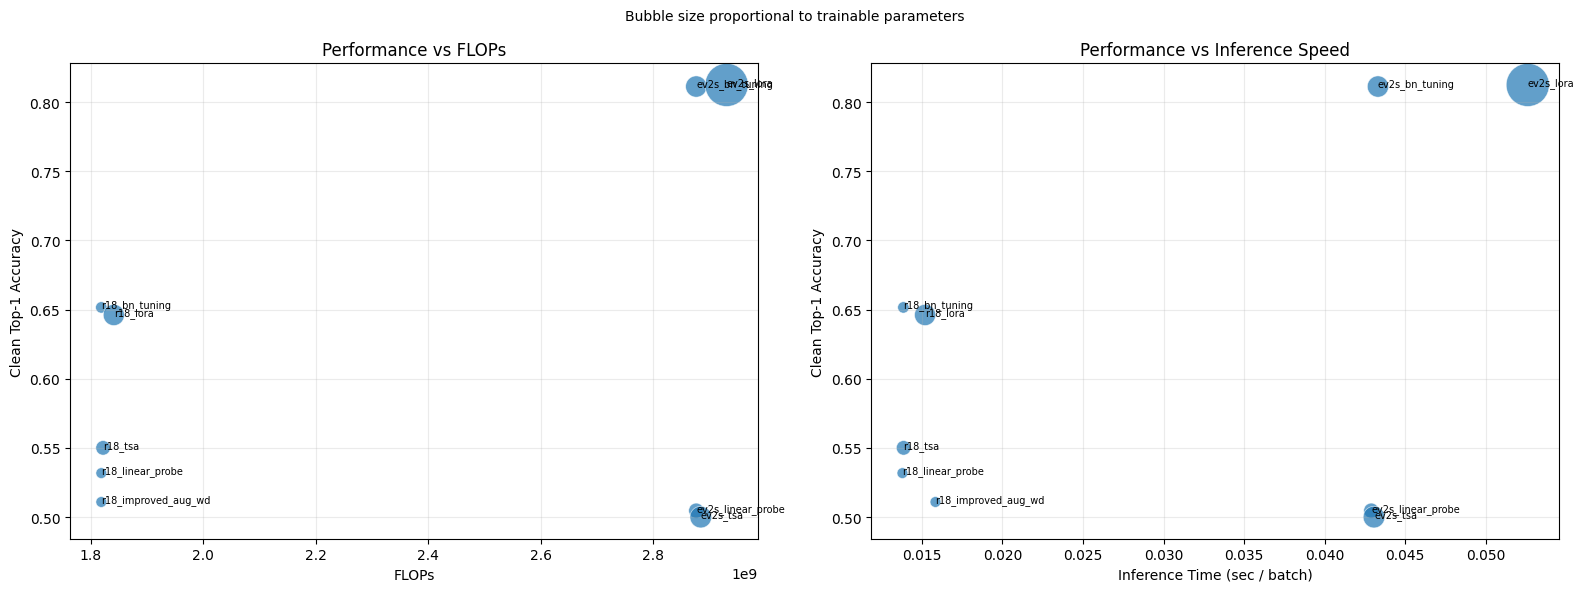

In [14]:
_raw = summary_df["trainable_params"]
_min, _max = _raw.min(), _raw.max()
bubble_sizes = 60 + 900 * (_raw - _min) / (_max - _min + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(
    summary_df["flops"], summary_df["clean_acc"],
    s=bubble_sizes, alpha=0.7, edgecolors="white", linewidth=0.5
)
for _, row in summary_df.iterrows():
    ax1.annotate(row["experiment"].replace("efficientnet_v2_s_", "ev2s_").replace("resnet18_", "r18_"),
                 (row["flops"], row["clean_acc"]), fontsize=7)
ax1.set_xlabel("FLOPs")
ax1.set_ylabel("Clean Top-1 Accuracy")
ax1.set_title("Performance vs FLOPs")
ax1.grid(True, alpha=0.25)

ax2.scatter(
    summary_df["inference_time_sec"], summary_df["clean_acc"],
    s=bubble_sizes, alpha=0.7, edgecolors="white", linewidth=0.5
)
for _, row in summary_df.iterrows():
    ax2.annotate(row["experiment"].replace("efficientnet_v2_s_", "ev2s_").replace("resnet18_", "r18_"),
                 (row["inference_time_sec"], row["clean_acc"]), fontsize=7)
ax2.set_xlabel("Inference Time (sec / batch)")
ax2.set_ylabel("Clean Top-1 Accuracy")
ax2.set_title("Performance vs Inference Speed")
ax2.grid(True, alpha=0.25)

plt.suptitle("Bubble size proportional to trainable parameters", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "figures", "bubble_plots.png"), dpi=200, bbox_inches="tight")
plt.show()

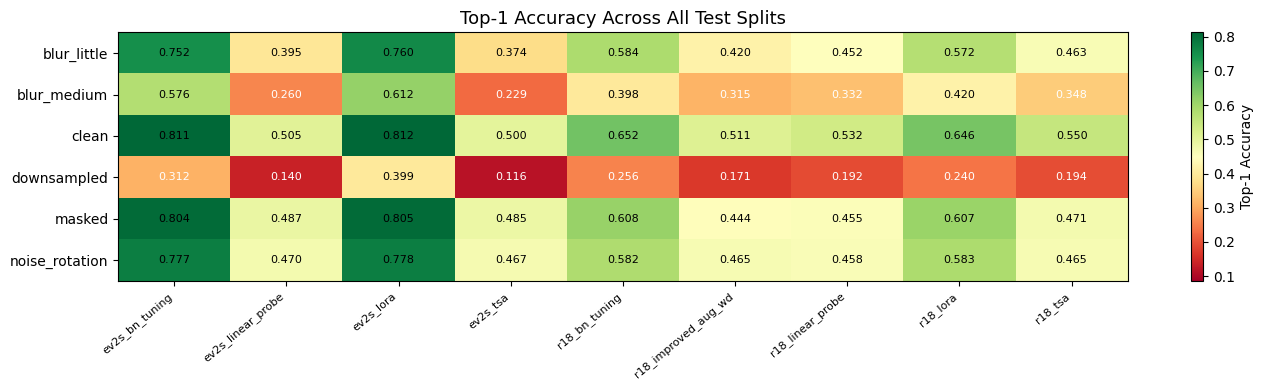

In [15]:
pivot_df = split_results_df.pivot(index="split", columns="experiment", values="accuracy")
col_labels = [
    c.replace("efficientnet_v2_s_", "ev2s_").replace("resnet18_", "r18_")
    for c in pivot_df.columns
]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_df.values, aspect="auto", cmap="RdYlGn",
               vmin=max(0, pivot_df.values[~np.isnan(pivot_df.values)].min() - 0.03))
ax.set_xticks(range(len(pivot_df.columns)))
ax.set_xticklabels(col_labels, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot_df.index)))
ax.set_yticklabels(pivot_df.index, fontsize=10)
plt.colorbar(im, ax=ax, label="Top-1 Accuracy")
for i in range(len(pivot_df.index)):
    for j in range(len(pivot_df.columns)):
        v = pivot_df.values[i, j]
        if not np.isnan(v):
            txt_col = "black" if v > 0.35 else "white"
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8, color=txt_col)
ax.set_title("Top-1 Accuracy Across All Test Splits", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "figures", "robustness_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

In [18]:
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def denormalize_image(tensor_img):
    img = tensor_img.detach().cpu().numpy().transpose(1, 2, 0)
    return (img * imagenet_std + imagenet_mean).clip(0, 1)


def get_target_layer(model, exp_name):
    if hasattr(model, "adapter") and hasattr(model, "backbone"):
        return [model.adapter]

    base = model.base_model.model if hasattr(model, "base_model") else model

    if "resnet18" in exp_name:
        return [base.layer4[-1].conv2]

    return [base.features[-1]]


def load_model_for_cam(exp_name):
    row   = summary_df[summary_df["experiment"] == exp_name].iloc[0]
    model = build_model(row["backbone"], row["method"])
    state = torch.load(row["checkpoint"], map_location=device, weights_only=False)
    model.load_state_dict(state, strict=False)
    model.to(device).eval()
    return model


def make_gradcam_figure(exp_name, split_name="clean", num_images=3):
    model = load_model_for_cam(exp_name)
    target_layers = get_target_layer(model, exp_name)

    x, y = next(iter(test_loaders[split_name]))
    x = x[:num_images].to(device)
    y = y[:num_images]

    # important for frozen-backbone models
    x = x.clone().detach().requires_grad_(True)

    with torch.no_grad():
        preds = model(x).argmax(dim=1)

    fig, axes = plt.subplots(num_images, 2, figsize=(8, 4 * num_images))
    if num_images == 1:
        axes = axes[np.newaxis, :]

    with GradCAM(model=model, target_layers=target_layers) as cam:
        for i in range(num_images):
            model.zero_grad(set_to_none=True)

            rgb = denormalize_image(x[i])
            targets = [ClassifierOutputTarget(int(preds[i].item()))]
            heatmap = cam(input_tensor=x[i:i+1], targets=targets)[0]
            cam_img = show_cam_on_image(rgb, heatmap, use_rgb=True)

            true_name = class_names[int(y[i])]
            pred_name = class_names[int(preds[i])]

            axes[i, 0].imshow(rgb)
            axes[i, 0].set_title(f"true: {true_name}\npred: {pred_name}", fontsize=8)
            axes[i, 0].axis("off")

            axes[i, 1].imshow(cam_img)
            axes[i, 1].set_title("Grad-CAM", fontsize=8)
            axes[i, 1].axis("off")

    plt.suptitle(f"{exp_name} [{split_name}]", fontsize=10)
    plt.tight_layout()
    out_path = os.path.join(save_dir, "figures", f"gradcam_{exp_name}_{split_name}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path

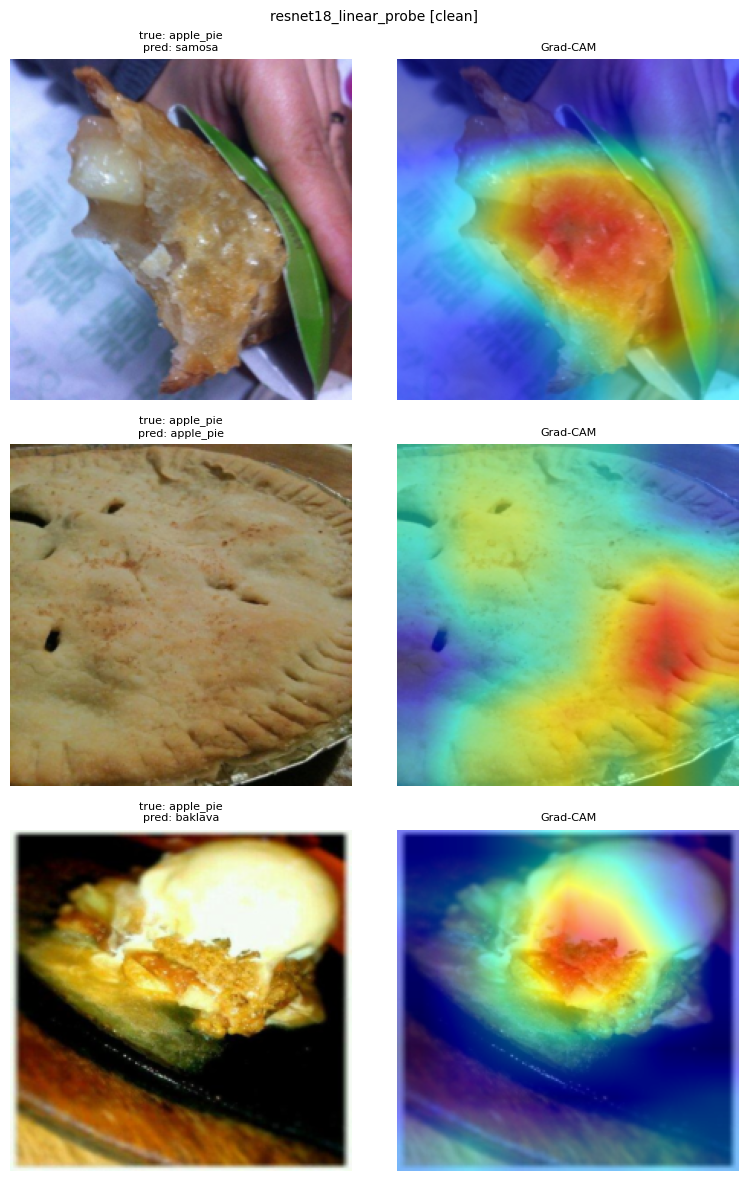

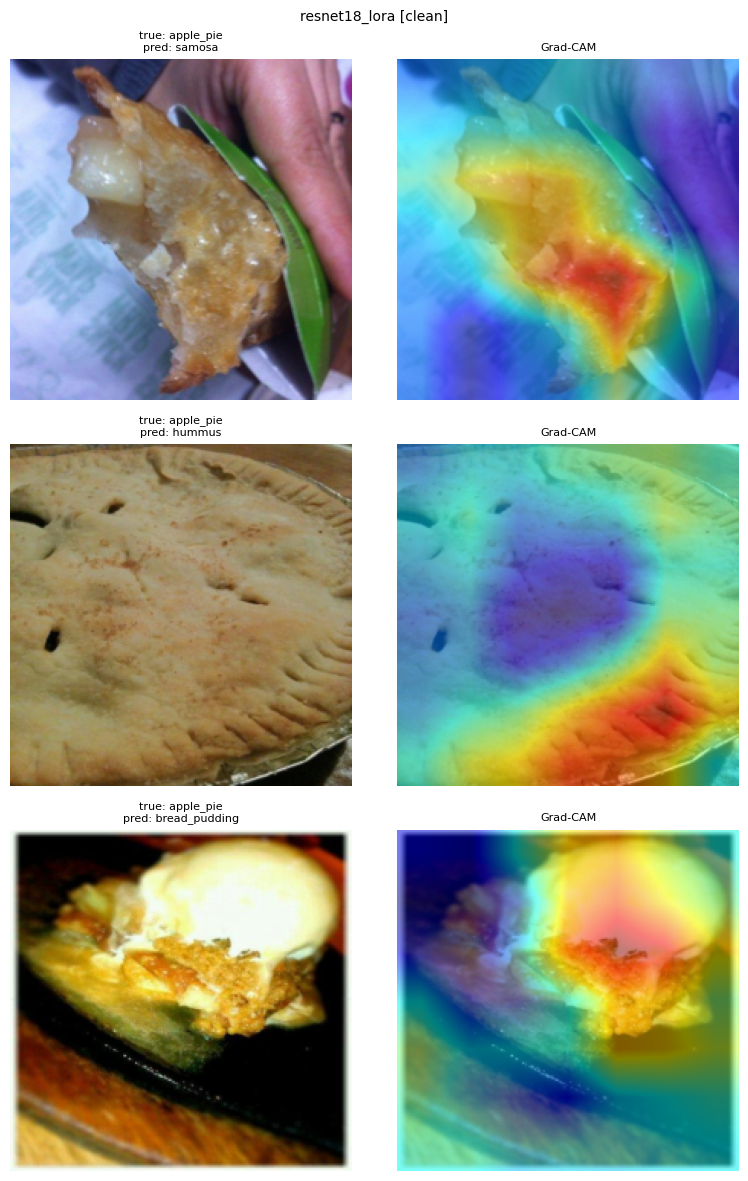

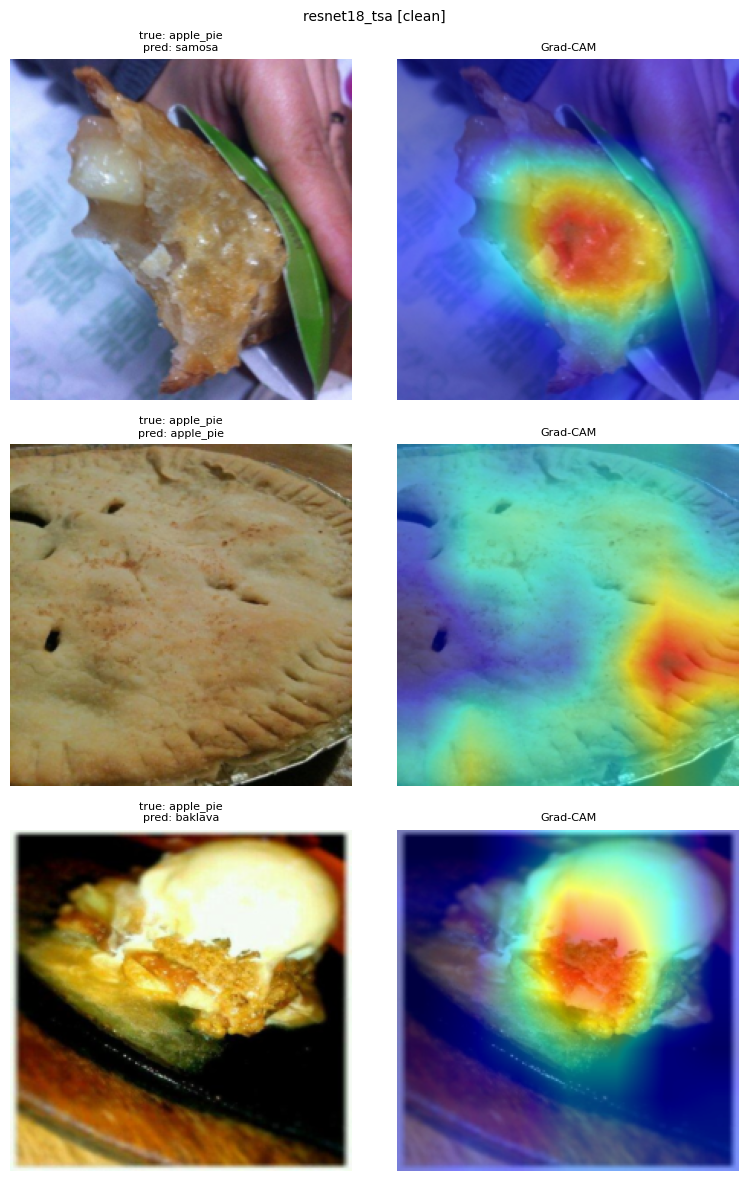

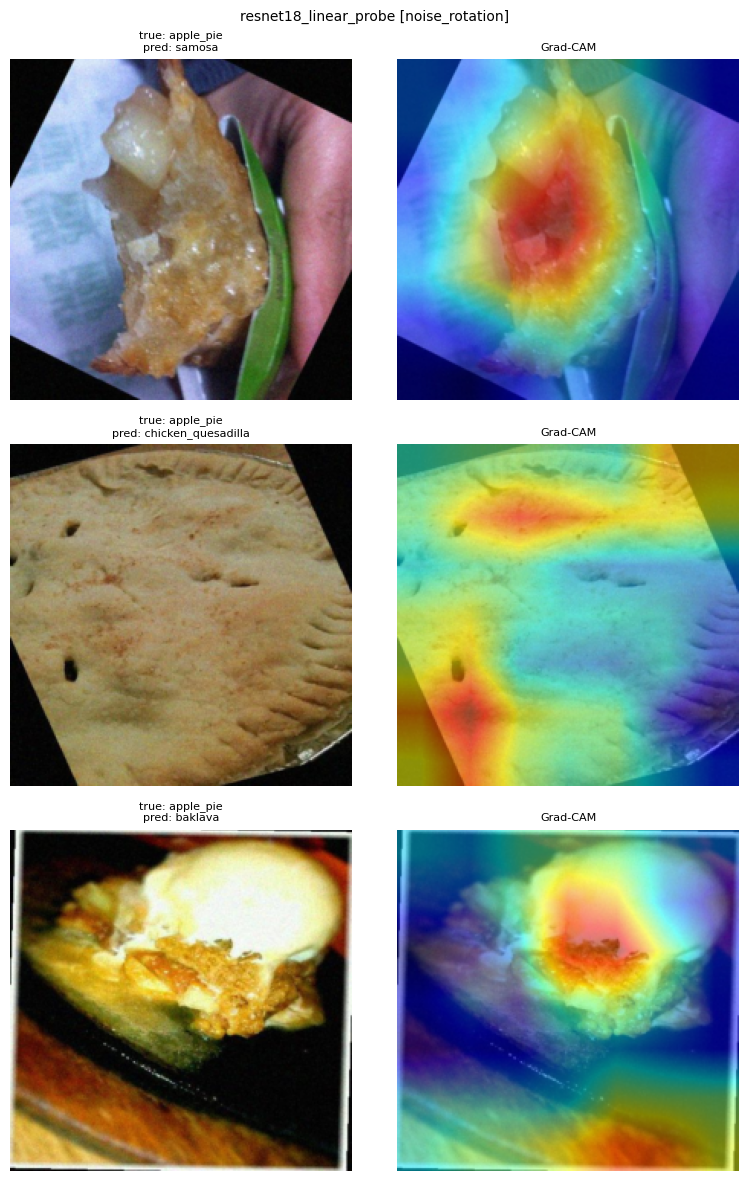

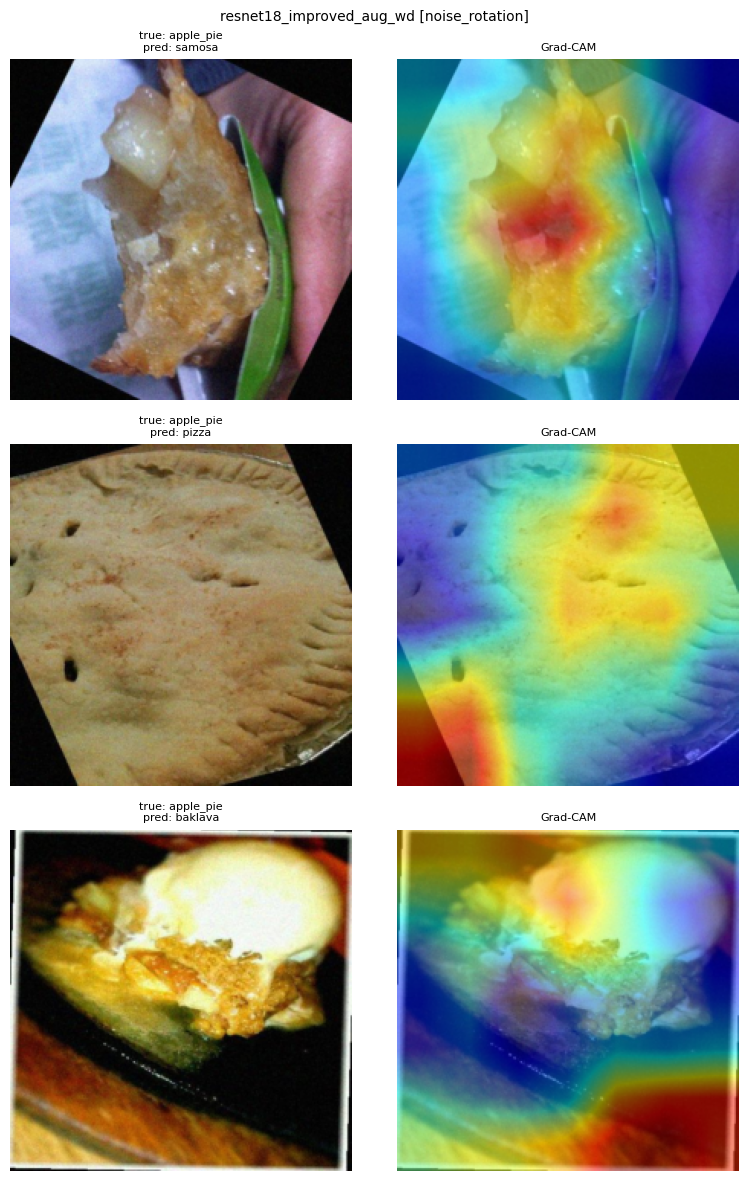

'./project_outputs\\figures\\gradcam_resnet18_improved_aug_wd_noise_rotation.png'

In [19]:
make_gradcam_figure("resnet18_linear_probe",  split_name="clean",         num_images=3)
make_gradcam_figure("resnet18_lora",            split_name="clean",         num_images=3)
make_gradcam_figure("resnet18_tsa",             split_name="clean",         num_images=3)
make_gradcam_figure("resnet18_linear_probe",  split_name="noise_rotation", num_images=3)
make_gradcam_figure("resnet18_improved_aug_wd", split_name="noise_rotation", num_images=3)